# Data Visualizations

In [13]:
import os
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
os.environ.setdefault("MLFLOW_TRACKING_URI", "file:///Users/dpham/mlruns_ml_pipeline")

from mlflow import MlflowClient
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.set_theme(context="paper", style="ticks", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

GREY = "#7a7a7a"
ACCENT = sns.color_palette("mako", n_colors=6)[2]

MODELS = {
    "Logistic Regression" : ("logistic_regression_survey_weights", "data/test_labeled_logistic_regression.parquet"),
    "XGBoost" : ("xgboost_survey_weights", "data/test_labeled_xgboost.parquet"),
    "Neural Network" : ("neural_network_survey_weights", "data/test_labeled_neural_network.parquet"),
}
MODEL_ORDER = list(MODELS.keys())
VARIANTS = ("standard", "survey_weighted")
TARGET = "Disability (recoded)_With a disability"
TEST_PARQUET = "data/test.parquet"
TRUE_POSITIVE_RATE = 0.1214

# For each (model, variant) pick the test run with the highest survey-weighted
# ROC-AUC (test_weighted_roc_auc), not merely the most recent.
client = MlflowClient()
rows = []
for model, (exp_name, _) in MODELS.items():
    exp = client.get_experiment_by_name(exp_name)
    for variant in VARIANTS:
        runs = client.search_runs(
            experiment_ids=[exp.experiment_id],
            filter_string=f"attributes.run_name = '{variant}_test'",
            order_by=["metrics.test_weighted_roc_auc DESC"],
            max_results=1,
        )
        for k, v in runs[0].data.metrics.items():
            if not k.startswith("test_"):
                continue
            _, weighting, metric = k.split("_", 2)
            rows.append({"model": model, "variant": variant,
                         "weighting": weighting, "metric": metric, "value": v})
metrics_df = pd.DataFrame(rows)

## Figure 1

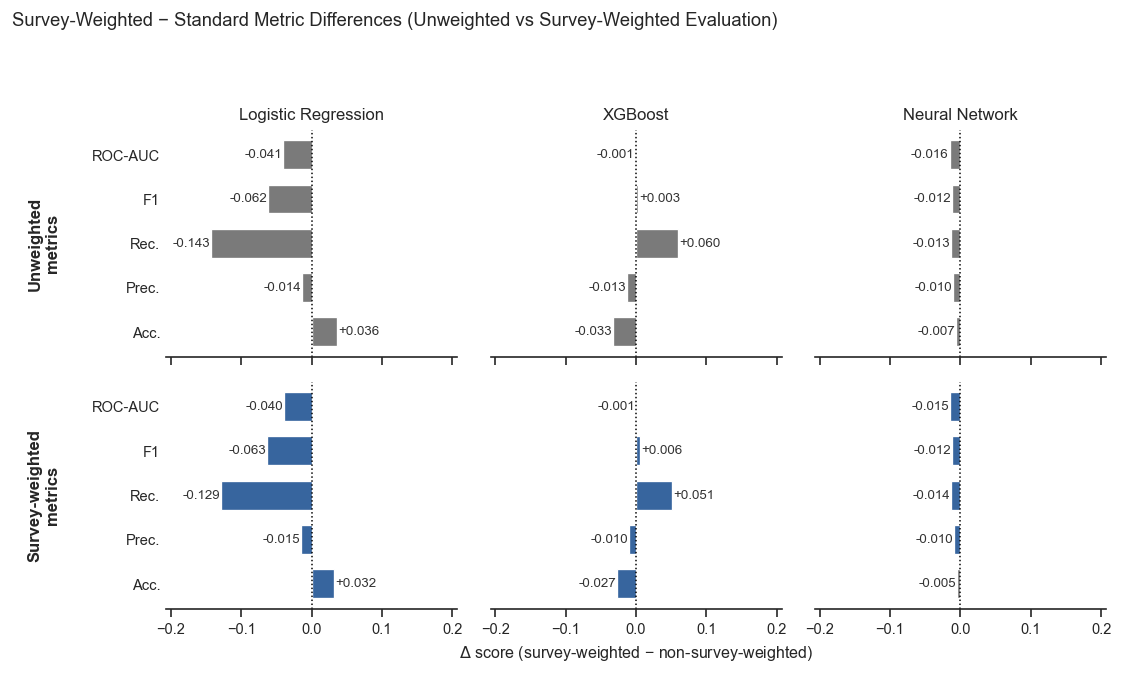

In [14]:
metric_order = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = {"accuracy": "Acc.", "precision": "Prec.", "recall": "Rec.",
                 "f1": "F1", "roc_auc": "ROC-AUC"}

delta_df = (metrics_df.pivot_table(index=["model", "weighting", "metric"],
                                   columns="variant", values="value")
                      .reset_index())
delta_df["delta"] = delta_df["survey_weighted"] - delta_df["standard"]

# Top row: deltas on the unweighted metrics; bottom row: deltas on the
# survey-weighted metrics from the MLflow-derived dataframe.
row_weightings = [("unweighted", "Unweighted\nmetrics"),
                  ("weighted", "Survey-weighted\nmetrics")]

fig, axes = plt.subplots(2, 3, figsize=(9.5, 5.6), sharex=True, sharey=True)
xmax = float(delta_df["delta"].abs().max()) * 1.45
for r, (weighting, rlabel) in enumerate(row_weightings):
    sub = delta_df[delta_df["weighting"] == weighting]
    for c, model in enumerate(MODEL_ORDER):
        ax = axes[r, c]
        row = sub[sub["model"] == model].set_index("metric").loc[metric_order]
        # Unweighted row is context (grey); survey-weighted row accents |Δ| > 0.005.
        if r == 0:
            colors = [GREY for _ in row["delta"]]
        else:
            colors = [ACCENT if abs(d) > 0.005 else GREY for d in row["delta"]]
        y_labels = [metric_labels[m] for m in metric_order]
        ax.barh(y_labels, row["delta"].values, color=colors, height=0.65)
        for y, d in enumerate(row["delta"].values):
            ax.text(d + (0.001 if d >= 0 else -0.001), y, f"{d:+.3f}",
                    ha="left" if d >= 0 else "right", va="center", fontsize=8,
                    color="#333333")
        ax.axvline(0, color="black", linewidth=0.9, linestyle=":")
        ax.set_xlim(-xmax, xmax)
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)
        ax.invert_yaxis()
        if r == 0:
            ax.set_title(model, fontsize=10)
    axes[r, 0].annotate(rlabel, xy=(-0.42, 0.5), xycoords="axes fraction",
                        rotation=90, ha="center", va="center",
                        fontsize=10, fontweight="bold")
axes[1, 1].set_xlabel(r"$\Delta$ score (survey-weighted − non-survey-weighted)")
fig.suptitle("Survey-Weighted − Standard Metric Differences (Unweighted vs Survey-Weighted Evaluation)",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0.03, 0, 1, 0.93])
plt.show()

## Figure 2

In [15]:
labeled = {name: pl.read_parquet(parquet) for name, (_, parquet) in MODELS.items()}
state_pop = pl.read_parquet(TEST_PARQUET, columns=["State population"])["State population"].to_numpy()

rate_rows = []
for model, df in labeled.items():
    for variant in VARIANTS:
        pred = df[f"predicted_disability_{variant}"].to_numpy()
        rate_rows.append({"model": model, "variant": variant, "weighting": "unweighted",
                          "rate": float(pred.mean())})
        rate_rows.append({"model": model, "variant": variant, "weighting": "population-weighted",
                          "rate": float((pred * state_pop).sum() / state_pop.sum())})
rate_df = pd.DataFrame(rate_rows)

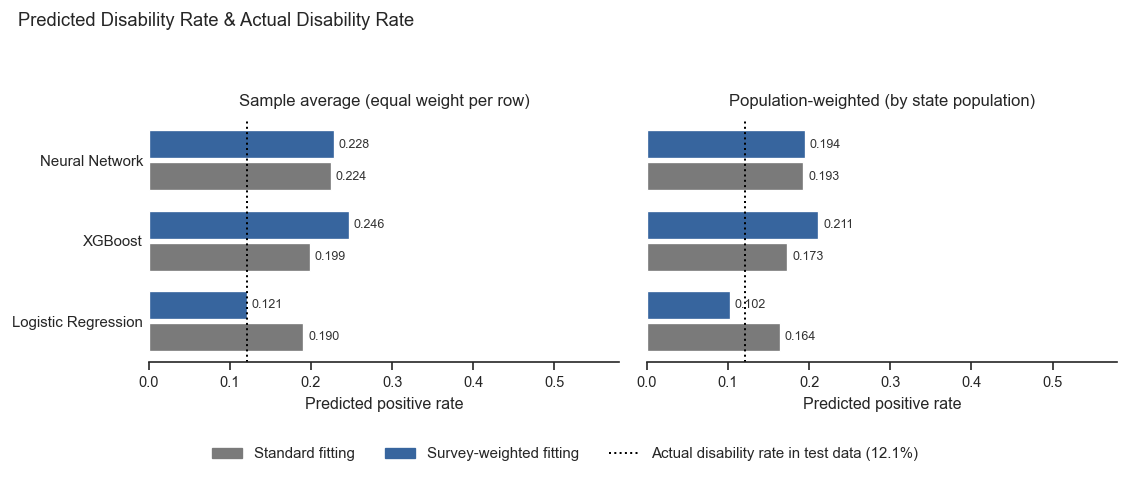

In [16]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharex=True, sharey=True)
y = np.arange(len(MODEL_ORDER))
subtitle_map = {
    "unweighted":          "Sample average (equal weight per row)",
    "population-weighted": "Population-weighted (by state population)",
}
for ax, weighting in zip(axes, ["unweighted", "population-weighted"]):
    sub = rate_df[rate_df["weighting"] == weighting]
    for j, variant in enumerate(VARIANTS):
        rates = [sub[(sub["model"] == m) & (sub["variant"] == variant)]["rate"].iloc[0]
                 for m in MODEL_ORDER]
        color = GREY if variant == "standard" else ACCENT
        offset = -0.2 if j == 0 else 0.2
        ax.barh(y + offset, rates, height=0.35, color=color)
        for i, r in enumerate(rates):
            ax.text(r + 0.006, i + offset, f"{r:.3f}", va="center",
                    fontsize=7.5, color="#333333")
    ax.axvline(TRUE_POSITIVE_RATE, color="black", linestyle=":", linewidth=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(MODEL_ORDER, fontsize=9)
    ax.set_xlim(0, 0.58)
    ax.set_xlabel("Predicted positive rate")
    ax.set_title(subtitle_map[weighting], fontsize=10, pad=8)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.invert_yaxis()

handles = [
    Patch(color=GREY,   label="Standard fitting"),
    Patch(color=ACCENT, label="Survey-weighted fitting"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.2,
           label=f"Actual disability rate in test data ({TRUE_POSITIVE_RATE:.1%})"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
           ncol=3, frameon=False, fontsize=9)

fig.suptitle("Predicted Disability Rate & Actual Disability Rate",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

## Figure 3

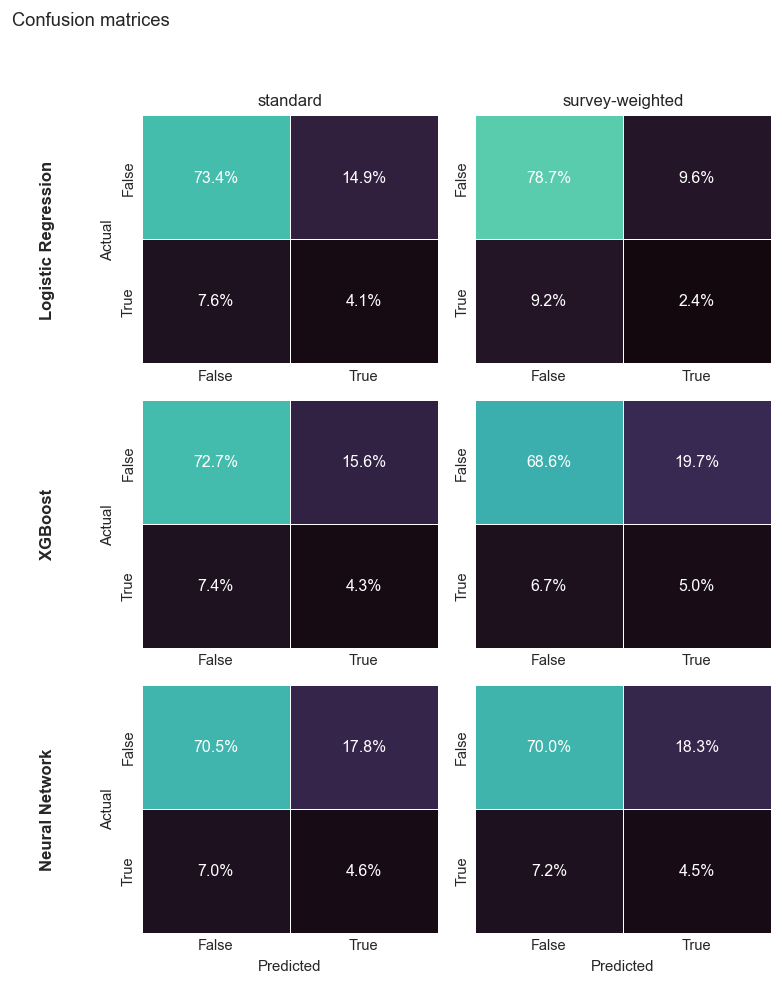

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(6.6, 8.2))
for i, (model, df) in enumerate(labeled.items()):
    y = df[TARGET].to_numpy()
    for j, variant in enumerate(VARIANTS):
        pred = df[f"predicted_disability_{variant}"].to_numpy()
        cm = confusion_matrix(y, pred, normalize="all") * 100
        annot = np.array([[f"{v:.1f}%" for v in row] for row in cm])
        sns.heatmap(cm, annot=annot, fmt="", cmap="mako", ax=axes[i, j],
                    cbar=False, vmin=0, vmax=100,
                    xticklabels=["False", "True"], yticklabels=["False", "True"],
                    annot_kws={"color": "white", "fontsize": 9.5},
                    linewidths=0.3, linecolor="white")
        if i == 0:
            axes[i, j].set_title(variant.replace("_", "-"), fontsize=10)
        axes[i, j].set_xlabel("Predicted" if i == 2 else "", fontsize=9)
        if j == 0:
            axes[i, j].set_ylabel("Actual", fontsize=9)
            axes[i, j].annotate(model, xy=(-0.32, 0.5), xycoords="axes fraction",
                                ha="center", va="center", rotation=90,
                                fontsize=10, fontweight="bold")
        else:
            axes[i, j].set_ylabel("")
        axes[i, j].tick_params(length=0)

fig.suptitle("Confusion matrices",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0.04, 0, 1, 0.965])
plt.show()

## Figure 4

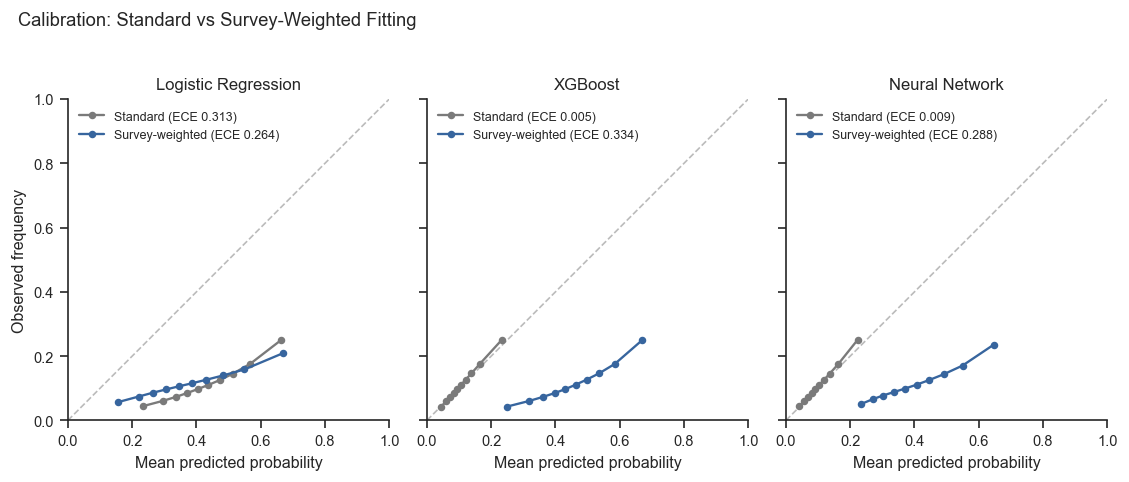

In [18]:
from sklearn.calibration import calibration_curve

N_BINS = 10

def ece(y_true, prob, n_bins=N_BINS):
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(prob, edges[1:-1])
    total = len(prob)
    err = 0.0
    for b in range(n_bins):
        m = idx == b
        if not m.any():
            continue
        err += (m.sum() / total) * abs(y_true[m].mean() - prob[m].mean())
    return err

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.7), sharex=True, sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    df = labeled[model]
    y = df[TARGET].to_numpy()
    ax.plot([0, 1], [0, 1], color="#bbbbbb", linestyle="--", linewidth=1, zorder=1)
    for variant in VARIANTS:
        prob = df[f"predicted_proba_{variant}"].to_numpy()
        frac_pos, mean_pred = calibration_curve(y, prob, n_bins=N_BINS, strategy="quantile")
        color = GREY if variant == "standard" else ACCENT
        label = "Standard" if variant == "standard" else "Survey-weighted"
        ax.plot(mean_pred, frac_pos, marker="o", markersize=3.5, linewidth=1.4,
                color=color, zorder=2, label=f"{label} (ECE {ece(y, prob):.3f})")
    ax.set_title(model, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_box_aspect(1)
    ax.set_xlabel("Mean predicted probability")
    ax.legend(loc="upper left", fontsize=7.5, frameon=False)
axes[0].set_ylabel("Observed frequency")
fig.suptitle("Calibration: Standard vs Survey-Weighted Fitting",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()